In [1]:
import os
os.environ["R_HOME"] = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R"

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"
os.environ["PATH"] = f"{qiime_env}/bin:/usr/local/bin:/usr/bin:/bin"
os.environ["CONDA_PREFIX"] = qiime_env


In [2]:
from pathlib import Path
import os

from ancombc2_heatmaps import (
    ANCOMBC2HeatmapPlotter,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec,
)

print("Imports ok")

Imports ok


In [3]:
BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum")
META = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt")

COLLAPSED_BASE = BASE / "collapsed_tables"
ANCOM_BASE = BASE / "exported"

OUT = BASE / "notebook_test"
OUT.mkdir(exist_ok=True)

print("BASE exists:", BASE.exists())
print("META exists:", META.exists())
print("COLLAPSED_BASE exists:", COLLAPSED_BASE.exists())
print("ANCOM_BASE exists:", ANCOM_BASE.exists())
print("OUT exists:", OUT.exists())

BASE exists: True
META exists: True
COLLAPSED_BASE exists: True
ANCOM_BASE exists: True
OUT exists: True


In [4]:
BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum")
META = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt")

COLLAPSED_BASE = BASE / "collapsed_tables"
ANCOM_BASE = BASE / "exported"

OUT = BASE / "notebook_test"
OUT.mkdir(exist_ok=True)

print("BASE exists:", BASE.exists())
print("META exists:", META.exists())
print("COLLAPSED_BASE exists:", COLLAPSED_BASE.exists())
print("ANCOM_BASE exists:", ANCOM_BASE.exists())
print("OUT exists:", OUT.exists())

BASE exists: True
META exists: True
COLLAPSED_BASE exists: True
ANCOM_BASE exists: True
OUT exists: True


In [5]:
print("COLLAPSED_BASE:")
print(sorted(os.listdir(COLLAPSED_BASE)))

print("\nANCOM_BASE:")
print(sorted(os.listdir(ANCOM_BASE)))

COLLAPSED_BASE:
['family', 'phylum']

ANCOM_BASE:
['family', 'phylum']


In [6]:
print("COLLAPSED_BASE:")
print(sorted(os.listdir(COLLAPSED_BASE)))

print("\nANCOM_BASE:")
print(sorted(os.listdir(ANCOM_BASE)))

COLLAPSED_BASE:
['family', 'phylum']

ANCOM_BASE:
['family', 'phylum']


In [8]:
FAMILY_TABLE_BASE = COLLAPSED_BASE / "family" / "by_sex"
FAMILY_ANCOM_BASE = ANCOM_BASE / "family" / "sex"

print("FAMILY_TABLE_BASE exists:", FAMILY_TABLE_BASE.exists())
print("FAMILY_ANCOM_BASE exists:", FAMILY_ANCOM_BASE.exists())

print("\nFamily table subdirs:")
print(sorted(os.listdir(FAMILY_TABLE_BASE)))

print("\nFamily ANCOM subdirs:")
print(sorted(os.listdir(FAMILY_ANCOM_BASE)))

FAMILY_TABLE_BASE exists: True
FAMILY_ANCOM_BASE exists: True

Family table subdirs:
['baseline1', 'baseline2', 'baseline3', 'day1', 'day14', 'day3', 'day7']

Family ANCOM subdirs:
['baseline1', 'baseline2', 'baseline3', 'day1', 'day14', 'day3', 'day7']


In [9]:
for tp in sorted(os.listdir(FAMILY_ANCOM_BASE)):
    p = FAMILY_ANCOM_BASE / tp
    if p.is_dir():
        print(f"\n--- FAMILY ANCOM {tp} ---")
        for fn in sorted(os.listdir(p)):
            print(fn)


--- FAMILY ANCOM baseline1 ---
table_baseline1_Apc_alltreat_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_Apc_irradiated_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_Apc_sham_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_WT_alltreat_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_WT_irradiated_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_WT_sham_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_all_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_irradiated_allgeno_family_ANCOM_sex_ANCOMBC2_exported
table_baseline1_sham_allgeno_family_ANCOM_sex_ANCOMBC2_exported

--- FAMILY ANCOM baseline2 ---
table_baseline2_Apc_alltreat_family_ANCOM_sex_ANCOMBC2_exported
table_baseline2_Apc_irradiated_family_ANCOM_sex_ANCOMBC2_exported
table_baseline2_Apc_sham_family_ANCOM_sex_ANCOMBC2_exported
table_baseline2_WT_alltreat_family_ANCOM_sex_ANCOMBC2_exported
table_baseline2_WT_irradiated_family_ANCOM_sex_ANCOMBC2_exported
table_baseline2_WT_sham_family_ANCOM_sex_ANCOMBC2_ex

In [10]:
TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_MAP = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",
    "baseline1": "baseline1",
    "baseline2": "baseline2",
    "baseline3": "baseline3",
    "day1": "day1",
    "day3": "day3",
    "day7": "day7",
    "day14": "day14",
}

In [11]:
family_heatmap_config = HeatmapConfig(
    metadata=MetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        comparison_col="sex",
        timepoints=TIMEPOINTS,
        timepoint_map=TIMEPOINT_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male", "female"],
        },
    ),
    comparison=ComparisonConfig(
        variable_name="sex",
        positive_class="male",
        negative_class="female",
    ),
    paths=PathConfig(
        base_table_dir=str(FAMILY_TABLE_BASE),
        base_ancom_dir=str(FAMILY_ANCOM_BASE),
        metadata_path=str(META),
        output_dir=str(OUT / "family_heatmaps"),
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMBC2_exported",
    ),
    cell_text_mode="relative_abundance",
    split_after_timepoint="baseline3",
    min_sig_cells_per_taxon=1,
)

In [12]:
family_plotter = ANCOMBC2HeatmapPlotter(family_heatmap_config)
family_meta = family_plotter.load_metadata()

print("Family metadata shape:", family_meta.shape)
print(family_meta[["sample_name", "time_point", "sex", "mice_model", "description_of_treatment"]].head())

Family metadata shape: (544, 72)
                     sample_name time_point   sex mice_model  \
0    16320.zr22868.68V3V4.S68.R1  baseline1  male        Apc   
1    16320.zr22868.91V3V4.S95.R1  baseline2  male        Apc   
2  16320.zr22868.391V3V4.S407.R1  baseline1  male        Apc   
3  16320.zr22868.407V3V4.S427.R1  baseline2  male        Apc   
4  16320.zr22868.227V3V4.S235.R1  baseline1  male        Apc   

  description_of_treatment  
0                     sham  
1                     sham  
2                     sham  
3                     sham  
4                     sham  


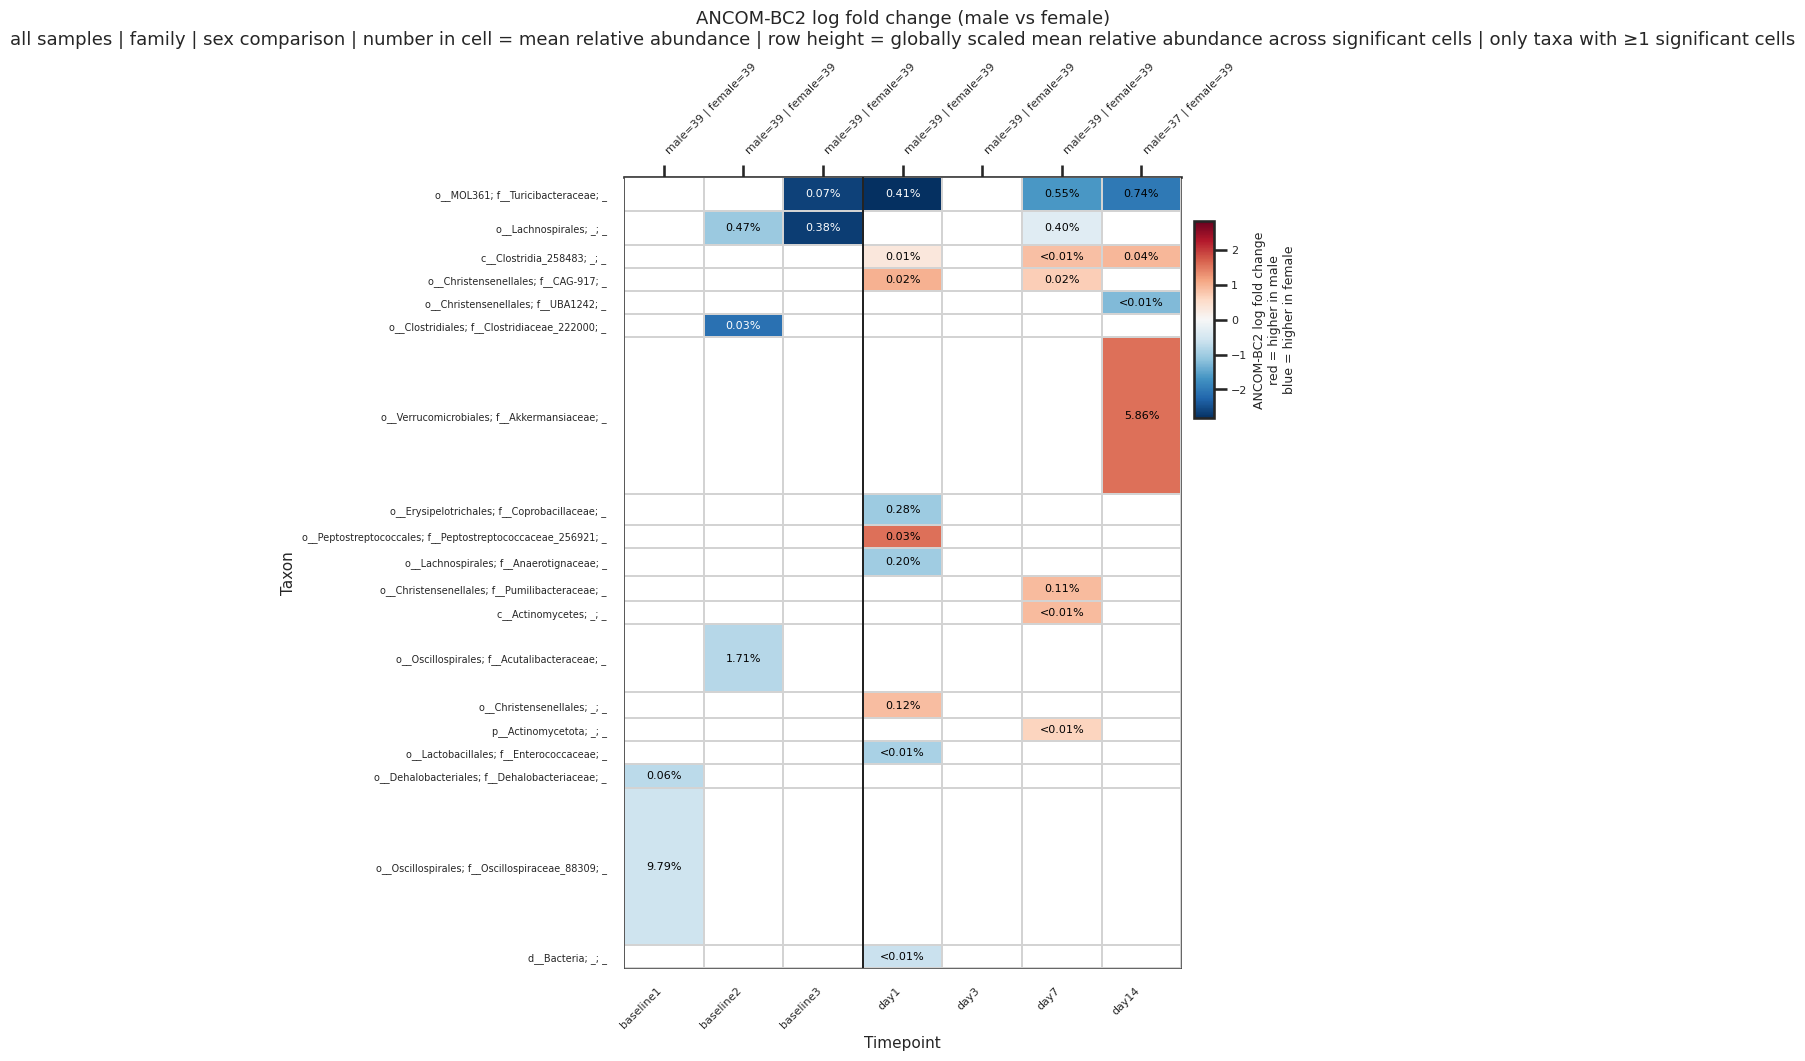

In [13]:
subset_family_all = SubsetSpec(
    label="all_family_ANCOM",
    title="all samples | family | sex comparison",
    filters={}
)

family_plotter.plot_subset(
    meta_df=family_meta,
    subset=subset_family_all,
    show=True,
    save_png=False,
    save_pdf=False,
)

In [14]:
from ancombc2_heatmaps import (
    TaxonTrajectoryPlotter,
    TrajectoryConfig,
    TrajectoryMetadataConfig,
    TrajectoryPathConfig,
    TrajectoryPlotConfig,
)

In [15]:
TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    0: "baseline",
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

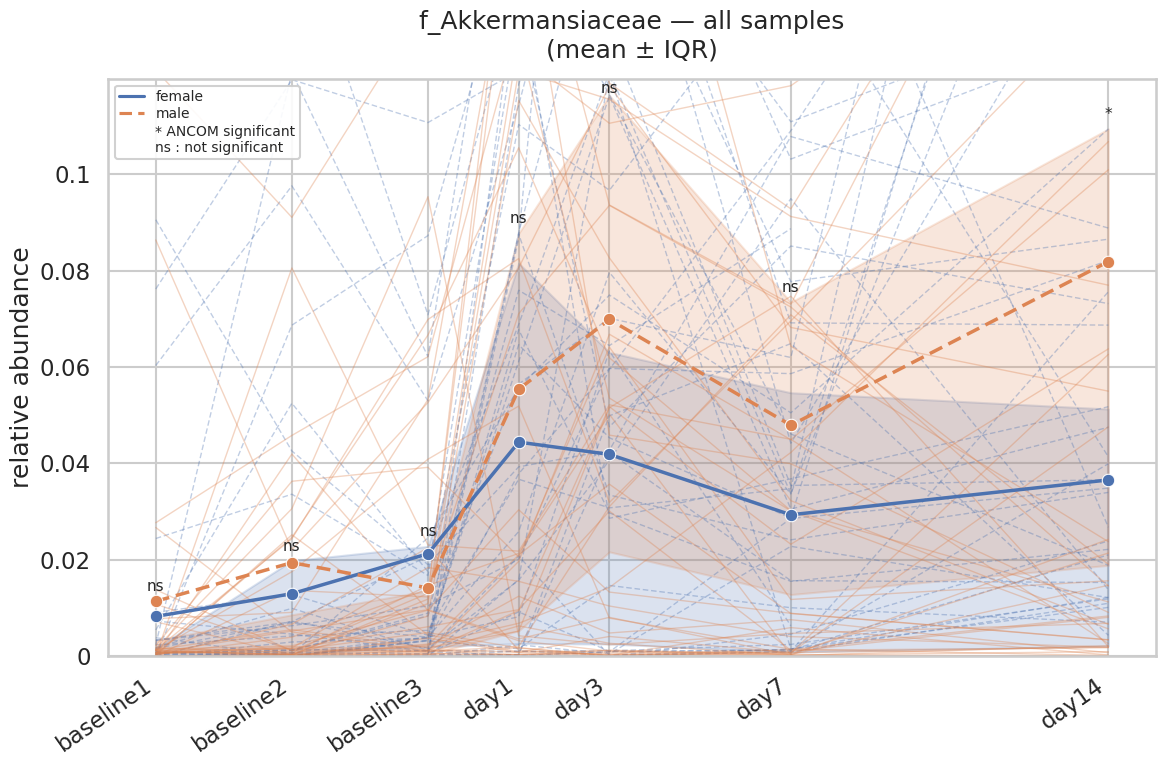

In [16]:
family_traj_config = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=str(META),
        table_base=str(COLLAPSED_BASE / "family" / "by_sex"),
        ancom_base=str(ANCOM_BASE / "family" / "sex"),
        table_suffix="family_ANCOM",
        ancom_export_suffix="ANCOMBC2_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=True,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={
            "female": "",
            "male": (4, 2),
        },
    ),
)

family_traj_plotter = TaxonTrajectoryPlotter(family_traj_config)

family_traj_plotter.plot_taxon(
    taxon_query="f_Akkermansiaceae",
    plot_mode="full",
    comparison_levels=["female", "male"],
)

In [23]:
PHYLUM_TABLE_BASE = COLLAPSED_BASE / "phylum" / "by_sex"
PHYLUM_ANCOM_BASE = ANCOM_BASE / "phylum" / "sex"

print("PHYLUM_TABLE_BASE exists:", PHYLUM_TABLE_BASE.exists())
print("PHYLUM_ANCOM_BASE exists:", PHYLUM_ANCOM_BASE.exists())

PHYLUM_TABLE_BASE exists: True
PHYLUM_ANCOM_BASE exists: True


In [24]:
phylum_heatmap_config = HeatmapConfig(
    metadata=MetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        comparison_col="sex",
        timepoints=TIMEPOINTS,
        timepoint_map=TIMEPOINT_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male", "female"],
        },
    ),
    comparison=ComparisonConfig(
        variable_name="sex",
        positive_class="male",
        negative_class="female",
    ),
    paths=PathConfig(
        base_table_dir=str(PHYLUM_TABLE_BASE),
        base_ancom_dir=str(PHYLUM_ANCOM_BASE),
        metadata_path=str(META),
        output_dir=str(HEATMAP_DIRS["phylum"]),
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMBC2_exported",
    ),
    cell_text_mode="relative_abundance",
    split_after_timepoint="baseline3",
    min_sig_cells_per_taxon=1,
)

In [25]:
phylum_plotter = ANCOMBC2HeatmapPlotter(phylum_heatmap_config)
phylum_meta = phylum_plotter.load_metadata()

print("phylum_plotter ok")
print("phylum_meta shape:", phylum_meta.shape)

phylum_plotter ok
phylum_meta shape: (544, 72)


In [26]:
phylum_traj_config = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=str(META),
        table_base=str(COLLAPSED_BASE / "phylum" / "by_sex"),
        ancom_base=str(ANCOM_BASE / "phylum" / "sex"),
        table_suffix="phylum_ANCOM",
        ancom_export_suffix="ANCOMBC2_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=True,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={
            "female": "",
            "male": (4, 2),
        },
    ),
)

phylum_traj_plotter = TaxonTrajectoryPlotter(phylum_traj_config)
print("phylum_traj_plotter ok")

phylum_traj_plotter ok


In [28]:
from pathlib import Path

# =========================================================
# OUTPUT STRUCTURE
# =========================================================

EXPORT_ROOT = OUT / "all_comparisons_exports"
EXPORT_ROOT.mkdir(exist_ok=True)

# =========================================================
# GLOBAL SETTINGS
# =========================================================

TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_MAP = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",
    "baseline1": "baseline1",
    "baseline2": "baseline2",
    "baseline3": "baseline3",
    "day1": "day1",
    "day3": "day3",
    "day7": "day7",
    "day14": "day14",
}

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["male", "female"],
    "mice_model": ["WT", "Apc"],
}

# =========================================================
# COMPARISON SETUPS
# =========================================================

comparison_setups = {
    "sex": {
        "comparison_col": "sex",
        "variable_name": "sex",
        "positive_class": "male",
        "negative_class": "female",
        "collapsed_subdir": "by_sex",
        "exported_subdir": "sex",
        "ancom_suffix": "sex_ANCOMBC2_exported",
        "subsets": [
            ("all", "all"),
            ("WT_alltreat", "WT | treatment pooled"),
            ("Apc_alltreat", "Apc | treatment pooled"),
            ("sham_allgeno", "sham | genotype pooled"),
            ("irradiated_allgeno", "irradiated | genotype pooled"),
            ("WT_sham", "WT | sham"),
            ("WT_irradiated", "WT | irradiated"),
            ("Apc_sham", "Apc | sham"),
            ("Apc_irradiated", "Apc | irradiated"),
        ],
    },
    "description_of_treatment": {
        "comparison_col": "description_of_treatment",
        "variable_name": "description_of_treatment",
        "positive_class": "irradiated",
        "negative_class": "sham",
        "collapsed_subdir": "by_treatment",
        "exported_subdir": "treatment",
        "ancom_suffix": "description_of_treatment_ANCOMBC2_exported",
        "subsets": [
            ("all", "all"),
            ("WT_allsex", "WT | sex pooled"),
            ("Apc_allsex", "Apc | sex pooled"),
            ("female_allgeno", "female | genotype pooled"),
            ("male_allgeno", "male | genotype pooled"),
            ("WT_female", "WT | female"),
            ("WT_male", "WT | male"),
            ("Apc_female", "Apc | female"),
            ("Apc_male", "Apc | male"),
        ],
    },
    "mice_model": {
        "comparison_col": "mice_model",
        "variable_name": "mice_model",
        "positive_class": "Apc",
        "negative_class": "WT",
        "collapsed_subdir": "by_mice_model",
        "exported_subdir": "mice_model",
        "ancom_suffix": "mice_model_ANCOMBC2_exported",
        "subsets": [
            ("all", "all"),
            ("sham_allsex", "sham | sex pooled"),
            ("irradiated_allsex", "irradiated | sex pooled"),
            ("female_alltreat", "female | treatment pooled"),
            ("male_alltreat", "male | treatment pooled"),
            ("female_sham", "female | sham"),
            ("female_irradiated", "female | irradiated"),
            ("male_sham", "male | sham"),
            ("male_irradiated", "male | irradiated"),
        ],
    },
}

# =========================================================
# TAXONOMY LEVELS
# =========================================================

taxonomy_levels = ["family", "phylum"]

# =========================================================
# HELPERS
# =========================================================

def make_heatmap_config(level, comp_key):
    cfg = comparison_setups[comp_key]

    table_base = COLLAPSED_BASE / level / cfg["collapsed_subdir"]
    ancom_base = ANCOM_BASE / level / cfg["exported_subdir"]

    outdir = EXPORT_ROOT / "heatmaps" / level / comp_key
    outdir.mkdir(parents=True, exist_ok=True)

    return HeatmapConfig(
        metadata=MetadataConfig(
            sample_col="sample_name",
            timepoint_col="time_point",
            comparison_col=cfg["comparison_col"],
            timepoints=TIMEPOINTS,
            timepoint_map=TIMEPOINT_MAP,
            allowed_values=COMMON_ALLOWED,
        ),
        comparison=ComparisonConfig(
            variable_name=cfg["variable_name"],
            positive_class=cfg["positive_class"],
            negative_class=cfg["negative_class"],
        ),
        paths=PathConfig(
            base_table_dir=str(table_base),
            base_ancom_dir=str(ancom_base),
            metadata_path=str(META),
            output_dir=str(outdir),
            table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
            ancom_template="{timepoint}/table_{timepoint}_{subset_label}_" + cfg["ancom_suffix"],
        ),
        cell_text_mode="relative_abundance",
        split_after_timepoint="baseline3",
        min_sig_cells_per_taxon=1,
    )

def make_subset(level, comp_key, subset_prefix, title):
    label = f"{subset_prefix}_{level}_ANCOM"
    return SubsetSpec(
        label=label,
        title=f"{title} | {level} | {comp_key}",
        filters={}
    )
import matplotlib.pyplot as plt
# =========================================================
# RUN ALL HEATMAP EXPORTS
# =========================================================

for level in taxonomy_levels:
    for comp_key in comparison_setups:
        print(f"\n=== HEATMAPS | level={level} | comparison={comp_key} ===")

        cfg = make_heatmap_config(level, comp_key)
        plotter = ANCOMBC2HeatmapPlotter(cfg)
        meta_df = plotter.load_metadata()

        for subset_prefix, title in comparison_setups[comp_key]["subsets"]:
            subset = make_subset(level, comp_key, subset_prefix, title)
        
            print(f"[HEATMAP] {level} | {comp_key} | {subset.label}")
        
            plotter.plot_subset(
                meta_df=meta_df,
                subset=subset,
                show=False,
                save_png=True,
                save_pdf=False,
            )
        
            # 🔑 verhindert Anzeige + Memory-Leaks
            plt.close("all")

print("\nAll heatmaps finished.")


=== HEATMAPS | level=family | comparison=sex ===
[HEATMAP] family | sex | all_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports/heatmaps/family/sex/ancombc2_lfc_heatmap_sex_all_family_ANCOM_min1sig.png
[HEATMAP] family | sex | WT_alltreat_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports/heatmaps/family/sex/ancombc2_lfc_heatmap_sex_WT_alltreat_family_ANCOM_min1sig.png
[HEATMAP] family | sex | Apc_alltreat_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports/heatmaps/family/sex/ancombc2_lfc_heatmap_sex_Apc_alltreat_family_ANCOM_min1sig.png
[HEATMAP] family | sex | sham_allgeno_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/a

In [29]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import qiime2
from biom import Table
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# =========================================================
# SETTINGS
# =========================================================

EXPORT_ROOT = OUT / "all_comparisons_exports"
EXPORT_ROOT.mkdir(exist_ok=True)

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["female", "male"],
    "mice_model": ["WT", "Apc"],
}

# Taxa to plot
family_taxa = [
    "f_Akkermansiaceae",
    "f_Lachnospiraceae",
    "f_Muribaculaceae",
]

phylum_taxa = [
    "p_Bacteroidota",
    "p_Verrucomicrobiota",
    "p_Actinomycetota",
]

TAXA_BY_LEVEL = {
    "family": family_taxa,
    "phylum": phylum_taxa,
}

# Comparison setups
comparison_setups = {
    "sex": {
        "comparison_col": "sex",
        "comparison_levels": ["female", "male"],
        "collapsed_subdir": "by_sex",
        "exported_subdir": "sex",
        "export_suffix": "sex_ANCOMBC2_exported",
        "line_styles": {"female": "", "male": (4, 2)},
        "subset_specs": [
            ("all", "all", {}),
            ("WT_alltreat", "WT | treatment pooled", {"mice_model": "WT"}),
            ("Apc_alltreat", "Apc | treatment pooled", {"mice_model": "Apc"}),
            ("sham_allgeno", "sham | genotype pooled", {"description_of_treatment": "sham"}),
            ("irradiated_allgeno", "irradiated | genotype pooled", {"description_of_treatment": "irradiated"}),
            ("WT_sham", "WT | sham", {"mice_model": "WT", "description_of_treatment": "sham"}),
            ("WT_irradiated", "WT | irradiated", {"mice_model": "WT", "description_of_treatment": "irradiated"}),
            ("Apc_sham", "Apc | sham", {"mice_model": "Apc", "description_of_treatment": "sham"}),
            ("Apc_irradiated", "Apc | irradiated", {"mice_model": "Apc", "description_of_treatment": "irradiated"}),
        ],
    },
    "description_of_treatment": {
        "comparison_col": "description_of_treatment",
        "comparison_levels": ["sham", "irradiated"],
        "collapsed_subdir": "by_treatment",
        "exported_subdir": "treatment",
        "export_suffix": "description_of_treatment_ANCOMBC2_exported",
        "line_styles": {"sham": "", "irradiated": (4, 2)},
        "subset_specs": [
            ("all", "all", {}),
            ("WT_allsex", "WT | sex pooled", {"mice_model": "WT"}),
            ("Apc_allsex", "Apc | sex pooled", {"mice_model": "Apc"}),
            ("female_allgeno", "female | genotype pooled", {"sex": "female"}),
            ("male_allgeno", "male | genotype pooled", {"sex": "male"}),
            ("WT_female", "WT | female", {"mice_model": "WT", "sex": "female"}),
            ("WT_male", "WT | male", {"mice_model": "WT", "sex": "male"}),
            ("Apc_female", "Apc | female", {"mice_model": "Apc", "sex": "female"}),
            ("Apc_male", "Apc | male", {"mice_model": "Apc", "sex": "male"}),
        ],
    },
    "mice_model": {
        "comparison_col": "mice_model",
        "comparison_levels": ["WT", "Apc"],
        "collapsed_subdir": "by_mice_model",
        "exported_subdir": "mice_model",
        "export_suffix": "mice_model_ANCOMBC2_exported",
        "line_styles": {"WT": "", "Apc": (4, 2)},
        "subset_specs": [
            ("all", "all", {}),
            ("sham_allsex", "sham | sex pooled", {"description_of_treatment": "sham"}),
            ("irradiated_allsex", "irradiated | sex pooled", {"description_of_treatment": "irradiated"}),
            ("female_alltreat", "female | treatment pooled", {"sex": "female"}),
            ("male_alltreat", "male | treatment pooled", {"sex": "male"}),
            ("female_sham", "female | sham", {"sex": "female", "description_of_treatment": "sham"}),
            ("female_irradiated", "female | irradiated", {"sex": "female", "description_of_treatment": "irradiated"}),
            ("male_sham", "male | sham", {"sex": "male", "description_of_treatment": "sham"}),
            ("male_irradiated", "male | irradiated", {"sex": "male", "description_of_treatment": "irradiated"}),
        ],
    },
}

sns.set_theme(style="whitegrid", context="talk")

# =========================================================
# HELPERS
# =========================================================

RANK_TO_PREFIX = {
    "d": "d__",
    "k": "k__",
    "p": "p__",
    "c": "c__",
    "o": "o__",
    "f": "f__",
    "g": "g__",
}

def clean_float_formatter(x, pos):
    return f"{x:.4f}".rstrip("0").rstrip(".")

def load_qza_table_as_df(qza_fp):
    art = qiime2.Artifact.load(str(qza_fp))
    table = art.view(Table)
    df = table.to_dataframe(dense=True)
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    return df

def clean_tax_piece(x):
    if x is None:
        return None
    x = str(x).strip()
    return x if x else None

def is_empty_tax(x):
    if x is None:
        return True
    stripped = re.sub(r"^[a-z]__+", "", str(x)).strip().lower()
    return stripped in {"", "uncultured", "unclassified", "unknown", "ambiguous_taxa"}

def normalize_taxon_label(raw_tax):
    if raw_tax is None:
        return "_; _; _"

    if isinstance(raw_tax, (list, tuple)):
        parts = [clean_tax_piece(x) for x in raw_tax]
    else:
        parts = [clean_tax_piece(x) for x in str(raw_tax).split(";")]

    parts = [x for x in parts if x is not None]

    tax_map = {}
    for p in parts:
        p = p.strip()
        if "__" in p:
            prefix = p.split("__", 1)[0].lower()
            if not is_empty_tax(p):
                tax_map[prefix] = p

    top_rank = None
    for rank in ["o", "c", "p", "k", "d"]:
        if rank in tax_map:
            top_rank = tax_map[rank]
            break

    family = tax_map.get("f")
    genus = tax_map.get("g")

    if top_rank is None:
        top_rank = "_"
    if family is None:
        family = "_"
    if genus is None:
        genus = "_"

    return f"{top_rank}; {family}; {genus}"

def parse_label(label):
    p = [x.strip() for x in str(label).split(";")]
    while len(p) < 3:
        p.append("_")
    return {"top": p[0], "family": p[1], "genus": p[2]}

def normalize_query(q):
    q = q.strip()

    if ";" in q:
        return {"mode": "exact", "value": q}

    m = re.match(r"([a-zA-Z])_(.+)", q)
    if m:
        r, name = m.group(1).lower(), m.group(2)
        if r not in RANK_TO_PREFIX:
            raise ValueError(f"Unsupported rank prefix: {r}")
        return {"mode": "rank", "rank": r, "value": RANK_TO_PREFIX[r] + name}

    raise ValueError("Invalid taxon_query")

def match_taxa(index, query):
    spec = normalize_query(query)
    matches = []

    for lab in index:
        parsed = parse_label(lab)

        if spec["mode"] == "exact":
            if lab == spec["value"]:
                matches.append(lab)
        else:
            r = spec["rank"]
            if r == "f" and parsed["family"] == spec["value"]:
                matches.append(lab)
            elif r == "g" and parsed["genus"] == spec["value"]:
                matches.append(lab)
            elif r in ["o", "c", "p", "k", "d"] and parsed["top"] == spec["value"]:
                matches.append(lab)

    return matches

def detect_effect_col(df, variable_name):
    candidates = [c for c in df.columns if c.startswith(f"{variable_name}::")]
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        return candidates[0]
    return None

def sig_to_label(is_sig):
    return "*" if is_sig else "ns"

def load_meta():
    m = pd.read_csv(META, sep="\t", dtype=str)
    m["tp"] = m["time_point"].map(TIMEPOINT_NUMERIC_MAP)

    for col in m.columns:
        if m[col].dtype == object:
            m[col] = m[col].astype(str).str.strip()

    for col, allowed in COMMON_ALLOWED.items():
        m = m[m[col].isin(allowed)].copy()

    return m

def apply_filters(df, filters):
    out = df.copy()
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            out = out[out[col].isin(list(val))].copy()
        else:
            out = out[out[col] == val].copy()
    return out

def get_table_qza_path(level, comp_key, tp, subset_prefix):
    table_base = COLLAPSED_BASE / level / comparison_setups[comp_key]["collapsed_subdir"]
    return table_base / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM.qza"

def get_ancom_export_dir(level, comp_key, tp, subset_prefix):
    ancom_base = ANCOM_BASE / level / comparison_setups[comp_key]["exported_subdir"]
    export_suffix = comparison_setups[comp_key]["export_suffix"]
    return ancom_base / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM_{export_suffix}"

def build_df_for_subset(meta, level, comp_key, subset_prefix, subset_filters, taxon_query):
    rows = []
    comparison_col = comparison_setups[comp_key]["comparison_col"]
    comparison_levels = comparison_setups[comp_key]["comparison_levels"]

    meta_subset = apply_filters(meta, subset_filters)
    meta_subset = meta_subset[meta_subset[comparison_col].isin(comparison_levels)].copy()

    for tp in TIMEPOINTS:
        fp = get_table_qza_path(level, comp_key, tp, subset_prefix)
        if not fp.exists():
            continue

        df = load_qza_table_as_df(fp)
        df.index = [normalize_taxon_label(x) for x in df.index]
        df = df.groupby(df.index).sum()

        col_sums = df.sum(axis=0)
        col_sums[col_sums == 0] = np.nan
        rel = df.div(col_sums, axis=1)

        matches = match_taxa(rel.index, taxon_query)
        if not matches:
            continue

        vals = rel.loc[matches].sum()

        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)
        m = meta_subset.copy()
        m = m[m["tp"] == tp_num]
        m = m[m["sample_name"].isin(vals.index)]

        for _, r in m.iterrows():
            rows.append([
                r["host_subject_id"],
                r[comparison_col],
                r["tp"],
                vals.get(r["sample_name"], np.nan),
            ])

    return pd.DataFrame(rows, columns=["mouse", "group", "tp", "abundance"]).dropna()

def build_sig_map(level, comp_key, subset_prefix, taxon_query, q_cutoff=0.05):
    sig_map = {}
    variable_name = comparison_setups[comp_key]["comparison_col"]

    for tp in TIMEPOINTS:
        export_dir = get_ancom_export_dir(level, comp_key, tp, subset_prefix)
        q_fp = export_dir / "q.jsonl"
        diff_fp = export_dir / "diff.jsonl"

        if not (export_dir.exists() and q_fp.exists() and diff_fp.exists()):
            continue

        q = pd.read_json(q_fp, lines=True)
        diff = pd.read_json(diff_fp, lines=True)

        effect_col = detect_effect_col(q, variable_name)
        if effect_col is None or effect_col not in diff.columns:
            continue

        tax_col_q = "taxon" if "taxon" in q.columns else q.columns[0]
        tax_col_diff = "taxon" if "taxon" in diff.columns else diff.columns[0]

        q_sub = q[[tax_col_q, effect_col]].rename(columns={tax_col_q: "taxon_raw", effect_col: "q"})
        diff_sub = diff[[tax_col_diff, effect_col]].rename(columns={tax_col_diff: "taxon_raw", effect_col: "diff"})

        tmp = q_sub.merge(diff_sub, on="taxon_raw", how="inner").copy()
        tmp["taxon"] = tmp["taxon_raw"].apply(normalize_taxon_label)
        tmp["significant"] = (tmp["q"] < q_cutoff) & (tmp["diff"] == True)

        sig_by_taxon = tmp.groupby("taxon", as_index=True)["significant"].any()

        matches = match_taxa(sig_by_taxon.index, taxon_query)
        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)

        if len(matches) == 0 or tp_num is None:
            sig_map[tp_num] = False
        else:
            sig_map[tp_num] = bool(sig_by_taxon.loc[matches].any())

    return sig_map

def apply_baseline(df, merge_baselines=False):
    df = df.copy()
    if merge_baselines:
        df["tp_plot"] = df["tp"].replace({
            -7: 0, -4: 0, -1: 0,
            1: 1, 3: 3, 7: 7, 14: 14
        })
    else:
        df["tp_plot"] = df["tp"]
    return df

def compute_ylim(dfs, estimator="mean", error_style="iqr", merge_baselines=False):
    upper_bounds = []

    for df in dfs:
        if df.empty:
            continue

        df_plot = apply_baseline(df, merge_baselines=merge_baselines)

        for _, g in df_plot.groupby(["tp_plot", "group"]):
            vals = pd.to_numeric(g["abundance"], errors="coerce").dropna().to_numpy()
            if len(vals) == 0:
                continue

            center = np.median(vals) if estimator == "median" else np.mean(vals)

            if error_style == "iqr":
                upper = np.percentile(vals, 75)
            else:
                rng = np.random.default_rng(42)
                func = np.median if estimator == "median" else np.mean
                boots = []
                for _ in range(1000):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boots.append(func(sample))
                upper = np.percentile(boots, 97.5)

            upper_bounds.append(max(center, upper))

    if not upper_bounds:
        return (0, 1)

    ymax = max(upper_bounds)
    if not np.isfinite(ymax) or ymax <= 0:
        return (0, 1)

    return (0, ymax * 1.03)

def get_visible_upper(g, estimator="mean", error_style="iqr"):
    uppers = []

    for _, gs in g.groupby("group"):
        vals = pd.to_numeric(gs["abundance"], errors="coerce").dropna().to_numpy()
        if len(vals) == 0:
            continue

        if error_style == "iqr":
            upper = np.percentile(vals, 75)
        else:
            rng = np.random.default_rng(42)
            func = np.median if estimator == "median" else np.mean
            boots = []
            for _ in range(1000):
                sample = rng.choice(vals, size=len(vals), replace=True)
                boots.append(func(sample))
            upper = np.percentile(boots, 97.5)

        center = np.median(vals) if estimator == "median" else np.mean(vals)
        uppers.append(max(center, upper))

    if len(uppers) == 0:
        return np.nan

    return max(uppers)

def sanitize_filename(s):
    s = str(s)
    s = s.replace(" ", "_")
    s = s.replace("|", "_")
    s = s.replace("/", "_")
    return s

def save_trajectory_plot(df, title, comparison_levels, line_styles, out_fp,
                         sig_map=None, merge_baselines=False, estimator="mean",
                         error_style="iqr", y_lim="auto_fix", show_individual_lines=True,
                         y_label="relative abundance"):
    if df.empty:
        print(f"[SKIP] No data: {title}")
        return

    df = apply_baseline(df, merge_baselines=merge_baselines)
    ylim = compute_ylim([df], estimator=estimator, error_style=error_style, merge_baselines=False) if y_lim == "auto_fix" else y_lim

    fig, ax = plt.subplots(figsize=(12, 8))

    dashes = line_styles if line_styles else True

    if show_individual_lines:
        sns.lineplot(
            data=df,
            x="tp_plot",
            y="abundance",
            hue="group",
            style="group",
            dashes=dashes,
            units="mouse",
            estimator=None,
            alpha=0.35,
            linewidth=1,
            legend=False,
            ax=ax
        )

    error_setting = ("ci", 95) if error_style == "ci" else ("pi", 50)

    sns.lineplot(
        data=df,
        x="tp_plot",
        y="abundance",
        hue="group",
        style="group",
        dashes=dashes,
        estimator=estimator,
        errorbar=error_setting,
        marker="o",
        linewidth=2.5,
        hue_order=comparison_levels,
        style_order=comparison_levels,
        ax=ax
    )

    estimator_label = "median" if estimator == "median" else "mean"
    err_label = "± 95% CI" if error_style == "ci" else "± IQR"

    ax.set_title(f"{title}\n({estimator_label} {err_label})", pad=15)
    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(FuncFormatter(clean_float_formatter))

    tp_vals = sorted(df["tp_plot"].dropna().unique())
    tp_labels = [TP_LABEL_MAP.get(tp, str(tp)) for tp in tp_vals]
    ax.set_xticks(tp_vals)
    ax.set_xticklabels(tp_labels, rotation=35, ha="right")

    if isinstance(ylim, tuple):
        ax.set_ylim(ylim)

    if sig_map is not None:
        y0, y1 = ax.get_ylim()
        y_range = y1 - y0
        offset = y_range * 0.012

        for tp_plot in sorted(df["tp_plot"].dropna().unique()):
            g = df[df["tp_plot"] == tp_plot]
            visible_upper = get_visible_upper(g, estimator=estimator, error_style=error_style)
            if pd.isna(visible_upper):
                continue

            original_tps = sorted(pd.to_numeric(g["tp"], errors="coerce").dropna().unique())
            if tp_plot == 0 and merge_baselines:
                is_sig = any(sig_map.get(tp_num, False) for tp_num in [-7, -4, -1])
            else:
                is_sig = any(sig_map.get(int(tp_num), False) for tp_num in original_tps)

            label = sig_to_label(is_sig)
            y = min(visible_upper + offset, y1 - y_range * 0.03)
            ax.text(tp_plot, y, label, ha="center", va="bottom", fontsize=11)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    clean_handles = []
    clean_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            clean_handles.append(h)
            clean_labels.append(l)
            seen.add(l)

    if sig_map is not None:
        star_legend = Line2D(
            [0], [0], color="black", lw=0,
            label="* ANCOM significant\nns : not significant"
        )
        clean_handles.append(star_legend)
        clean_labels.append(star_legend.get_label())

    ax.legend(
        handles=clean_handles,
        labels=clean_labels,
        loc="upper left",
        fontsize=10,
        frameon=True,
        framealpha=0.9,
        borderpad=0.3,
        labelspacing=0.25,
        handlelength=1.8
    )

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# RUN ALL TRAJECTORY EXPORTS
# =========================================================

meta = load_meta()

for level, taxa_list in TAXA_BY_LEVEL.items():
    for comp_key, comp_cfg in comparison_setups.items():
        outdir = EXPORT_ROOT / "trajectories" / level / comp_key
        outdir.mkdir(parents=True, exist_ok=True)

        print(f"\n=== TRAJECTORIES | level={level} | comparison={comp_key} ===")

        for subset_prefix, subset_title, subset_filters in comp_cfg["subset_specs"]:
            for taxon_query in taxa_list:
                df = build_df_for_subset(
                    meta=meta,
                    level=level,
                    comp_key=comp_key,
                    subset_prefix=subset_prefix,
                    subset_filters=subset_filters,
                    taxon_query=taxon_query,
                )

                sig_map = build_sig_map(
                    level=level,
                    comp_key=comp_key,
                    subset_prefix=subset_prefix,
                    taxon_query=taxon_query,
                    q_cutoff=0.05,
                )

                title = f"{taxon_query} — {subset_title} | {level} | compare {comp_key}"
                fname = f"{sanitize_filename(taxon_query)}__{sanitize_filename(level)}__{sanitize_filename(comp_key)}__{sanitize_filename(subset_prefix)}.png"

                print(f"[TRAJ] {level} | {comp_key} | {subset_prefix} | {taxon_query}")

                save_trajectory_plot(
                    df=df,
                    title=title,
                    comparison_levels=comp_cfg["comparison_levels"],
                    line_styles=comp_cfg["line_styles"],
                    out_fp=outdir / fname,
                    sig_map=sig_map,
                    merge_baselines=False,
                    estimator="mean",
                    error_style="iqr",
                    y_lim="auto_fix",
                    show_individual_lines=True,
                    y_label="relative abundance",
                )

print("\nAll trajectory plots finished.")
print("Saved under:", EXPORT_ROOT / "trajectories")


=== TRAJECTORIES | level=family | comparison=sex ===
[TRAJ] family | sex | all | f_Akkermansiaceae
[TRAJ] family | sex | all | f_Lachnospiraceae
[TRAJ] family | sex | all | f_Muribaculaceae
[TRAJ] family | sex | WT_alltreat | f_Akkermansiaceae
[TRAJ] family | sex | WT_alltreat | f_Lachnospiraceae
[TRAJ] family | sex | WT_alltreat | f_Muribaculaceae
[TRAJ] family | sex | Apc_alltreat | f_Akkermansiaceae
[TRAJ] family | sex | Apc_alltreat | f_Lachnospiraceae
[TRAJ] family | sex | Apc_alltreat | f_Muribaculaceae
[TRAJ] family | sex | sham_allgeno | f_Akkermansiaceae
[TRAJ] family | sex | sham_allgeno | f_Lachnospiraceae
[TRAJ] family | sex | sham_allgeno | f_Muribaculaceae
[TRAJ] family | sex | irradiated_allgeno | f_Akkermansiaceae
[TRAJ] family | sex | irradiated_allgeno | f_Lachnospiraceae
[TRAJ] family | sex | irradiated_allgeno | f_Muribaculaceae
[TRAJ] family | sex | WT_sham | f_Akkermansiaceae
[TRAJ] family | sex | WT_sham | f_Lachnospiraceae
[TRAJ] family | sex | WT_sham | f_Muri

In [30]:
print("FAMILY by_treatment:")
for tp in sorted(os.listdir(COLLAPSED_BASE / "family" / "by_treatment")):
    p = COLLAPSED_BASE / "family" / "by_treatment" / tp
    if p.is_dir():
        print(f"\n--- {tp} ---")
        for fn in sorted(os.listdir(p)):
            print(fn)

print("\nFAMILY exported treatment:")
for tp in sorted(os.listdir(ANCOM_BASE / "family" / "treatment")):
    p = ANCOM_BASE / "family" / "treatment" / tp
    if p.is_dir():
        print(f"\n--- {tp} ---")
        for fn in sorted(os.listdir(p)):
            print(fn)

FAMILY by_treatment:

--- baseline1 ---
table_baseline1_Apc_allsex_family_ANCOM.qza
table_baseline1_WT_allsex_family_ANCOM.qza
table_baseline1_all_family_ANCOM.qza
table_baseline1_female_Apc_family_ANCOM.qza
table_baseline1_female_WT_family_ANCOM.qza
table_baseline1_female_allgeno_family_ANCOM.qza
table_baseline1_male_Apc_family_ANCOM.qza
table_baseline1_male_WT_family_ANCOM.qza
table_baseline1_male_allgeno_family_ANCOM.qza

--- baseline2 ---
table_baseline2_Apc_allsex_family_ANCOM.qza
table_baseline2_WT_allsex_family_ANCOM.qza
table_baseline2_all_family_ANCOM.qza
table_baseline2_female_Apc_family_ANCOM.qza
table_baseline2_female_WT_family_ANCOM.qza
table_baseline2_female_allgeno_family_ANCOM.qza
table_baseline2_male_Apc_family_ANCOM.qza
table_baseline2_male_WT_family_ANCOM.qza
table_baseline2_male_allgeno_family_ANCOM.qza

--- baseline3 ---
table_baseline3_Apc_allsex_family_ANCOM.qza
table_baseline3_WT_allsex_family_ANCOM.qza
table_baseline3_all_family_ANCOM.qza
table_baseline3_female

In [31]:
print("PHYLUM by_treatment:")
for tp in sorted(os.listdir(COLLAPSED_BASE / "phylum" / "by_treatment")):
    p = COLLAPSED_BASE / "phylum" / "by_treatment" / tp
    if p.is_dir():
        print(f"\n--- {tp} ---")
        for fn in sorted(os.listdir(p)):
            print(fn)

print("\nPHYLUM exported treatment:")
for tp in sorted(os.listdir(ANCOM_BASE / "phylum" / "treatment")):
    p = ANCOM_BASE / "phylum" / "treatment" / tp
    if p.is_dir():
        print(f"\n--- {tp} ---")
        for fn in sorted(os.listdir(p)):
            print(fn)

PHYLUM by_treatment:

--- baseline1 ---
table_baseline1_Apc_allsex_phylum_ANCOM.qza
table_baseline1_WT_allsex_phylum_ANCOM.qza
table_baseline1_all_phylum_ANCOM.qza
table_baseline1_female_Apc_phylum_ANCOM.qza
table_baseline1_female_WT_phylum_ANCOM.qza
table_baseline1_female_allgeno_phylum_ANCOM.qza
table_baseline1_male_Apc_phylum_ANCOM.qza
table_baseline1_male_WT_phylum_ANCOM.qza
table_baseline1_male_allgeno_phylum_ANCOM.qza

--- baseline2 ---
table_baseline2_Apc_allsex_phylum_ANCOM.qza
table_baseline2_WT_allsex_phylum_ANCOM.qza
table_baseline2_all_phylum_ANCOM.qza
table_baseline2_female_Apc_phylum_ANCOM.qza
table_baseline2_female_WT_phylum_ANCOM.qza
table_baseline2_female_allgeno_phylum_ANCOM.qza
table_baseline2_male_Apc_phylum_ANCOM.qza
table_baseline2_male_WT_phylum_ANCOM.qza
table_baseline2_male_allgeno_phylum_ANCOM.qza

--- baseline3 ---
table_baseline3_Apc_allsex_phylum_ANCOM.qza
table_baseline3_WT_allsex_phylum_ANCOM.qza
table_baseline3_all_phylum_ANCOM.qza
table_baseline3_female

In [32]:
from pathlib import Path

EXPORT_ROOT = OUT / "all_comparisons_exports_v2"

HEATMAP_ROOT = EXPORT_ROOT / "heatmaps"
TRAJ_ROOT = EXPORT_ROOT / "trajectories"

for d in [HEATMAP_ROOT, TRAJ_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

print("New export root:", EXPORT_ROOT)

New export root: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports_v2


In [33]:
import matplotlib.pyplot as plt

# =========================================================
# COMPARISON SETUPS (FIXED)
# =========================================================

comparison_setups = {
    "sex": {
        "comparison_col": "sex",
        "variable_name": "sex",
        "positive_class": "male",
        "negative_class": "female",
        "collapsed_subdir": "by_sex",
        "exported_subdir": "sex",
        "ancom_suffix": "sex_ANCOMBC2_exported",
        "subsets": [
            ("all", "all"),
            ("WT_alltreat", "WT | treatment pooled"),
            ("Apc_alltreat", "Apc | treatment pooled"),
            ("sham_allgeno", "sham | genotype pooled"),
            ("irradiated_allgeno", "irradiated | genotype pooled"),
            ("WT_sham", "WT | sham"),
            ("WT_irradiated", "WT | irradiated"),
            ("Apc_sham", "Apc | sham"),
            ("Apc_irradiated", "Apc | irradiated"),
        ],
    },
    "description_of_treatment": {
        "comparison_col": "description_of_treatment",
        "variable_name": "description_of_treatment",
        "positive_class": "irradiated",
        "negative_class": "sham",
        "collapsed_subdir": "by_treatment",
        "exported_subdir": "treatment",
        "ancom_suffix": "treatment_ANCOMBC2_exported",
        "subsets": [
            ("all", "all"),
            ("WT_allsex", "WT | sex pooled"),
            ("Apc_allsex", "Apc | sex pooled"),
            ("female_allgeno", "female | genotype pooled"),
            ("male_allgeno", "male | genotype pooled"),
            ("female_WT", "female | WT"),
            ("female_Apc", "female | Apc"),
            ("male_WT", "male | WT"),
            ("male_Apc", "male | Apc"),
        ],
    },
    "mice_model": {
        "comparison_col": "mice_model",
        "variable_name": "mice_model",
        "positive_class": "Apc",
        "negative_class": "WT",
        "collapsed_subdir": "by_mice_model",
        "exported_subdir": "mice_model",
        "ancom_suffix": "mice_model_ANCOMBC2_exported",
        "subsets": [
            ("all", "all"),
            ("sham_allsex", "sham | sex pooled"),
            ("irradiated_allsex", "irradiated | sex pooled"),
            ("female_alltreat", "female | treatment pooled"),
            ("male_alltreat", "male | treatment pooled"),
            ("female_sham", "female | sham"),
            ("female_irradiated", "female | irradiated"),
            ("male_sham", "male | sham"),
            ("male_irradiated", "male | irradiated"),
        ],
    },
}

taxonomy_levels = ["family", "phylum"]

# =========================================================
# RUN HEATMAP EXPORTS
# =========================================================

for level in taxonomy_levels:
    for comp_key in comparison_setups:
        print(f"\n=== HEATMAPS | {level} | {comp_key} ===")

        cfg = make_heatmap_config(level, comp_key)
        cfg.paths.output_dir = str(HEATMAP_ROOT / level / comp_key)

        plotter = ANCOMBC2HeatmapPlotter(cfg)
        meta_df = plotter.load_metadata()

        for subset_prefix, title in comparison_setups[comp_key]["subsets"]:
            subset = make_subset(level, comp_key, subset_prefix, title)

            print(f"[HEATMAP] {subset.label}")

            plotter.plot_subset(
                meta_df=meta_df,
                subset=subset,
                show=False,
                save_png=True,
                save_pdf=False,
            )

            plt.close("all")

print("\nHeatmaps done.")


=== HEATMAPS | family | sex ===
[HEATMAP] all_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports_v2/heatmaps/family/sex/ancombc2_lfc_heatmap_sex_all_family_ANCOM_min1sig.png
[HEATMAP] WT_alltreat_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports_v2/heatmaps/family/sex/ancombc2_lfc_heatmap_sex_WT_alltreat_family_ANCOM_min1sig.png
[HEATMAP] Apc_alltreat_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports_v2/heatmaps/family/sex/ancombc2_lfc_heatmap_sex_Apc_alltreat_family_ANCOM_min1sig.png
[HEATMAP] sham_allgeno_family_ANCOM
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports_v2/heatmaps/family/sex/ancombc2_lfc_heatmap_s

In [36]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import qiime2
from biom import Table
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# =========================================================
# OUTPUT ROOT
# =========================================================

EXPORT_ROOT = OUT / "all_comparisons_exports_v2"
TRAJ_ROOT = EXPORT_ROOT / "trajectories"
TRAJ_ROOT.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["female", "male"],
    "mice_model": ["WT", "Apc"],
}

family_taxa = [
    "f_Akkermansiaceae",
    "f_Lachnospiraceae",
    "f_Muribaculaceae",
]

phylum_taxa = [
    "p_Bacteroidota",
    "p_Verrucomicrobiota",
    "p_Actinomycetota",
]

TAXA_BY_LEVEL = {
    "family": family_taxa,
    "phylum": phylum_taxa,
}

trajectory_comparison_setups = {
    "sex": {
        "comparison_col": "sex",
        "comparison_levels": ["female", "male"],
        "collapsed_subdir": "by_sex",
        "exported_subdir": "sex",
        "export_suffix": "sex_ANCOMBC2_exported",
        "line_styles": {"female": "", "male": (4, 2)},
        "subset_specs": [
            ("all", "all", {}),
            ("WT_alltreat", "WT | treatment pooled", {"mice_model": "WT"}),
            ("Apc_alltreat", "Apc | treatment pooled", {"mice_model": "Apc"}),
            ("sham_allgeno", "sham | genotype pooled", {"description_of_treatment": "sham"}),
            ("irradiated_allgeno", "irradiated | genotype pooled", {"description_of_treatment": "irradiated"}),
            ("WT_sham", "WT | sham", {"mice_model": "WT", "description_of_treatment": "sham"}),
            ("WT_irradiated", "WT | irradiated", {"mice_model": "WT", "description_of_treatment": "irradiated"}),
            ("Apc_sham", "Apc | sham", {"mice_model": "Apc", "description_of_treatment": "sham"}),
            ("Apc_irradiated", "Apc | irradiated", {"mice_model": "Apc", "description_of_treatment": "irradiated"}),
        ],
    },
    "description_of_treatment": {
        "comparison_col": "description_of_treatment",
        "comparison_levels": ["sham", "irradiated"],
        "collapsed_subdir": "by_treatment",
        "exported_subdir": "treatment",
        "export_suffix": "treatment_ANCOMBC2_exported",
        "line_styles": {"sham": "", "irradiated": (4, 2)},
        "subset_specs": [
            ("all", "all", {}),
            ("WT_allsex", "WT | sex pooled", {"mice_model": "WT"}),
            ("Apc_allsex", "Apc | sex pooled", {"mice_model": "Apc"}),
            ("female_allgeno", "female | genotype pooled", {"sex": "female"}),
            ("male_allgeno", "male | genotype pooled", {"sex": "male"}),
            ("female_WT", "female | WT", {"sex": "female", "mice_model": "WT"}),
            ("female_Apc", "female | Apc", {"sex": "female", "mice_model": "Apc"}),
            ("male_WT", "male | WT", {"sex": "male", "mice_model": "WT"}),
            ("male_Apc", "male | Apc", {"sex": "male", "mice_model": "Apc"}),
        ],
    },
    "mice_model": {
        "comparison_col": "mice_model",
        "comparison_levels": ["WT", "Apc"],
        "collapsed_subdir": "by_mice_model",
        "exported_subdir": "mice_model",
        "export_suffix": "mice_model_ANCOMBC2_exported",
        "line_styles": {"WT": "", "Apc": (4, 2)},
        "subset_specs": [
            ("all", "all", {}),
            ("sham_allsex", "sham | sex pooled", {"description_of_treatment": "sham"}),
            ("irradiated_allsex", "irradiated | sex pooled", {"description_of_treatment": "irradiated"}),
            ("female_alltreat", "female | treatment pooled", {"sex": "female"}),
            ("male_alltreat", "male | treatment pooled", {"sex": "male"}),
            ("female_sham", "female | sham", {"sex": "female", "description_of_treatment": "sham"}),
            ("female_irradiated", "female | irradiated", {"sex": "female", "description_of_treatment": "irradiated"}),
            ("male_sham", "male | sham", {"sex": "male", "description_of_treatment": "sham"}),
            ("male_irradiated", "male | irradiated", {"sex": "male", "description_of_treatment": "irradiated"}),
        ],
    },
}

sns.set_theme(style="whitegrid", context="talk")

# =========================================================
# HELPERS
# =========================================================

RANK_TO_PREFIX = {
    "d": "d__",
    "k": "k__",
    "p": "p__",
    "c": "c__",
    "o": "o__",
    "f": "f__",
    "g": "g__",
}

def clean_float_formatter(x, pos):
    return f"{x:.4f}".rstrip("0").rstrip(".")

def load_qza_table_as_df(qza_fp):
    art = qiime2.Artifact.load(str(qza_fp))
    table = art.view(Table)
    df = table.to_dataframe(dense=True)
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    return df

def clean_tax_piece(x):
    if x is None:
        return None
    x = str(x).strip()
    return x if x else None

def is_empty_tax(x):
    if x is None:
        return True
    stripped = re.sub(r"^[a-z]__+", "", str(x)).strip().lower()
    return stripped in {"", "uncultured", "unclassified", "unknown", "ambiguous_taxa"}

def normalize_taxon_label(raw_tax):
    if raw_tax is None:
        return "_; _; _"

    if isinstance(raw_tax, (list, tuple)):
        parts = [clean_tax_piece(x) for x in raw_tax]
    else:
        parts = [clean_tax_piece(x) for x in str(raw_tax).split(";")]

    parts = [x for x in parts if x is not None]

    tax_map = {}
    for p in parts:
        p = p.strip()
        if "__" in p:
            prefix = p.split("__", 1)[0].lower()
            if not is_empty_tax(p):
                tax_map[prefix] = p

    top_rank = None
    for rank in ["o", "c", "p", "k", "d"]:
        if rank in tax_map:
            top_rank = tax_map[rank]
            break

    family = tax_map.get("f")
    genus = tax_map.get("g")

    if top_rank is None:
        top_rank = "_"
    if family is None:
        family = "_"
    if genus is None:
        genus = "_"

    return f"{top_rank}; {family}; {genus}"

def parse_label(label):
    p = [x.strip() for x in str(label).split(";")]
    while len(p) < 3:
        p.append("_")
    return {"top": p[0], "family": p[1], "genus": p[2]}

def normalize_query(q):
    q = q.strip()

    if ";" in q:
        return {"mode": "exact", "value": q}

    m = re.match(r"([a-zA-Z])_(.+)", q)
    if m:
        r, name = m.group(1).lower(), m.group(2)
        if r not in RANK_TO_PREFIX:
            raise ValueError(f"Unsupported rank prefix: {r}")
        return {"mode": "rank", "rank": r, "value": RANK_TO_PREFIX[r] + name}

    raise ValueError("Invalid taxon_query")

def match_taxa(index, query):
    spec = normalize_query(query)
    matches = []

    for lab in index:
        parsed = parse_label(lab)

        if spec["mode"] == "exact":
            if lab == spec["value"]:
                matches.append(lab)
        else:
            r = spec["rank"]
            if r == "f" and parsed["family"] == spec["value"]:
                matches.append(lab)
            elif r == "g" and parsed["genus"] == spec["value"]:
                matches.append(lab)
            elif r in ["o", "c", "p", "k", "d"] and parsed["top"] == spec["value"]:
                matches.append(lab)

    return matches

def detect_effect_col(df, variable_name):
    candidates = [c for c in df.columns if c.startswith(f"{variable_name}::")]
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        return candidates[0]
    return None

def sig_to_label(is_sig):
    return "*" if is_sig else "ns"

def load_meta():
    m = pd.read_csv(META, sep="\t", dtype=str)
    m["tp"] = m["time_point"].map(TIMEPOINT_NUMERIC_MAP)

    for col in m.columns:
        if m[col].dtype == object:
            m[col] = m[col].astype(str).str.strip()

    for col, allowed in COMMON_ALLOWED.items():
        m = m[m[col].isin(allowed)].copy()

    return m

def apply_filters(df, filters):
    out = df.copy()
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            out = out[out[col].isin(list(val))].copy()
        else:
            out = out[out[col] == val].copy()
    return out

def get_table_qza_path(level, comp_key, tp, subset_prefix):
    table_base = COLLAPSED_BASE / level / trajectory_comparison_setups[comp_key]["collapsed_subdir"]
    return table_base / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM.qza"

def get_ancom_export_dir(level, comp_key, tp, subset_prefix):
    ancom_base = ANCOM_BASE / level / trajectory_comparison_setups[comp_key]["exported_subdir"]
    export_suffix = trajectory_comparison_setups[comp_key]["export_suffix"]
    return ancom_base / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM_{export_suffix}"

def build_df_for_subset(meta, level, comp_key, subset_prefix, subset_filters, taxon_query):
    rows = []
    comparison_col = trajectory_comparison_setups[comp_key]["comparison_col"]
    comparison_levels = trajectory_comparison_setups[comp_key]["comparison_levels"]

    meta_subset = apply_filters(meta, subset_filters)
    meta_subset = meta_subset[meta_subset[comparison_col].isin(comparison_levels)].copy()

    for tp in TIMEPOINTS:
        fp = get_table_qza_path(level, comp_key, tp, subset_prefix)
        if not fp.exists():
            continue

        df = load_qza_table_as_df(fp)
        df.index = [normalize_taxon_label(x) for x in df.index]
        df = df.groupby(df.index).sum()

        col_sums = df.sum(axis=0)
        col_sums[col_sums == 0] = np.nan
        rel = df.div(col_sums, axis=1)

        matches = match_taxa(rel.index, taxon_query)
        if not matches:
            continue

        vals = rel.loc[matches].sum()

        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)
        m = meta_subset.copy()
        m = m[m["tp"] == tp_num]
        m = m[m["sample_name"].isin(vals.index)]

        for _, r in m.iterrows():
            rows.append([
                r["host_subject_id"],
                r[comparison_col],
                r["tp"],
                vals.get(r["sample_name"], np.nan),
            ])

    return pd.DataFrame(rows, columns=["mouse", "group", "tp", "abundance"]).dropna()

def build_sig_map(level, comp_key, subset_prefix, taxon_query, q_cutoff=0.05):
    sig_map = {}
    variable_name = trajectory_comparison_setups[comp_key]["comparison_col"]

    for tp in TIMEPOINTS:
        export_dir = get_ancom_export_dir(level, comp_key, tp, subset_prefix)
        q_fp = export_dir / "q.jsonl"
        diff_fp = export_dir / "diff.jsonl"

        if not (export_dir.exists() and q_fp.exists() and diff_fp.exists()):
            continue

        q = pd.read_json(q_fp, lines=True)
        diff = pd.read_json(diff_fp, lines=True)

        effect_col = detect_effect_col(q, variable_name)
        if effect_col is None or effect_col not in diff.columns:
            continue

        tax_col_q = "taxon" if "taxon" in q.columns else q.columns[0]
        tax_col_diff = "taxon" if "taxon" in diff.columns else diff.columns[0]

        q_sub = q[[tax_col_q, effect_col]].rename(columns={tax_col_q: "taxon_raw", effect_col: "q"})
        diff_sub = diff[[tax_col_diff, effect_col]].rename(columns={tax_col_diff: "taxon_raw", effect_col: "diff"})

        tmp = q_sub.merge(diff_sub, on="taxon_raw", how="inner").copy()
        tmp["taxon"] = tmp["taxon_raw"].apply(normalize_taxon_label)
        tmp["significant"] = (tmp["q"] < q_cutoff) & (tmp["diff"] == True)

        sig_by_taxon = tmp.groupby("taxon", as_index=True)["significant"].any()

        matches = match_taxa(sig_by_taxon.index, taxon_query)
        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)

        if len(matches) == 0 or tp_num is None:
            sig_map[tp_num] = False
        else:
            sig_map[tp_num] = bool(sig_by_taxon.loc[matches].any())

    return sig_map

def apply_baseline(df, merge_baselines=False):
    df = df.copy()
    if merge_baselines:
        df["tp_plot"] = df["tp"].replace({
            -7: 0, -4: 0, -1: 0,
            1: 1, 3: 3, 7: 7, 14: 14
        })
    else:
        df["tp_plot"] = df["tp"]
    return df

def compute_ylim(dfs, estimator="mean", error_style="iqr", merge_baselines=False):
    upper_bounds = []

    for df in dfs:
        if df.empty:
            continue

        df_plot = apply_baseline(df, merge_baselines=merge_baselines)

        for _, g in df_plot.groupby(["tp_plot", "group"]):
            vals = pd.to_numeric(g["abundance"], errors="coerce").dropna().to_numpy()
            if len(vals) == 0:
                continue

            center = np.median(vals) if estimator == "median" else np.mean(vals)

            if error_style == "iqr":
                upper = np.percentile(vals, 75)
            else:
                rng = np.random.default_rng(42)
                func = np.median if estimator == "median" else np.mean
                boots = []
                for _ in range(1000):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boots.append(func(sample))
                upper = np.percentile(boots, 97.5)

            upper_bounds.append(max(center, upper))

    if not upper_bounds:
        return (0, 1)

    ymax = max(upper_bounds)
    if not np.isfinite(ymax) or ymax <= 0:
        return (0, 1)

    return (0, ymax * 1.03)

def get_visible_upper(g, estimator="mean", error_style="iqr"):
    uppers = []

    for _, gs in g.groupby("group"):
        vals = pd.to_numeric(gs["abundance"], errors="coerce").dropna().to_numpy()
        if len(vals) == 0:
            continue

        if error_style == "iqr":
            upper = np.percentile(vals, 75)
        else:
            rng = np.random.default_rng(42)
            func = np.median if estimator == "median" else np.mean
            boots = []
            for _ in range(1000):
                sample = rng.choice(vals, size=len(vals), replace=True)
                boots.append(func(sample))
            upper = np.percentile(boots, 97.5)

        center = np.median(vals) if estimator == "median" else np.mean(vals)
        uppers.append(max(center, upper))

    if len(uppers) == 0:
        return np.nan

    return max(uppers)

def sanitize_filename(s):
    s = str(s)
    s = s.replace(" ", "_").replace("|", "_").replace("/", "_")
    return s

def save_trajectory_plot(df, title, comparison_levels, line_styles, out_fp,
                         sig_map=None, merge_baselines=False, estimator="mean",
                         error_style="iqr", y_lim="auto_fix", show_individual_lines=True,
                         y_label="relative abundance"):
    if df.empty:
        print(f"[SKIP] No data: {title}")
        return

    df = apply_baseline(df, merge_baselines=merge_baselines)
    ylim = compute_ylim([df], estimator=estimator, error_style=error_style, merge_baselines=False) if y_lim == "auto_fix" else y_lim

    fig, ax = plt.subplots(figsize=(12, 8))

    dashes = line_styles if line_styles else True

    if show_individual_lines:
        sns.lineplot(
            data=df,
            x="tp_plot",
            y="abundance",
            hue="group",
            style="group",
            dashes=dashes,
            units="mouse",
            estimator=None,
            alpha=0.35,
            linewidth=1,
            legend=False,
            ax=ax
        )

    error_setting = ("ci", 95) if error_style == "ci" else ("pi", 50)

    sns.lineplot(
        data=df,
        x="tp_plot",
        y="abundance",
        hue="group",
        style="group",
        dashes=dashes,
        estimator=estimator,
        errorbar=error_setting,
        marker="o",
        linewidth=2.5,
        hue_order=comparison_levels,
        style_order=comparison_levels,
        ax=ax
    )

    estimator_label = "median" if estimator == "median" else "mean"
    err_label = "± 95% CI" if error_style == "ci" else "± IQR"

    ax.set_title(f"{title}\n({estimator_label} {err_label})", pad=15)
    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(FuncFormatter(clean_float_formatter))

    tp_vals = sorted(df["tp_plot"].dropna().unique())
    tp_labels = [TP_LABEL_MAP.get(tp, str(tp)) for tp in tp_vals]
    ax.set_xticks(tp_vals)
    ax.set_xticklabels(tp_labels, rotation=35, ha="right")

    if isinstance(ylim, tuple):
        ax.set_ylim(ylim)

    if sig_map is not None:
        y0, y1 = ax.get_ylim()
        y_range = y1 - y0
        offset = y_range * 0.012

        for tp_plot in sorted(df["tp_plot"].dropna().unique()):
            g = df[df["tp_plot"] == tp_plot]
            visible_upper = get_visible_upper(g, estimator=estimator, error_style=error_style)
            if pd.isna(visible_upper):
                continue

            original_tps = sorted(pd.to_numeric(g["tp"], errors="coerce").dropna().unique())
            if tp_plot == 0 and merge_baselines:
                is_sig = any(sig_map.get(tp_num, False) for tp_num in [-7, -4, -1])
            else:
                is_sig = any(sig_map.get(int(tp_num), False) for tp_num in original_tps)

            label = sig_to_label(is_sig)
            y = min(visible_upper + offset, y1 - y_range * 0.03)
            ax.text(tp_plot, y, label, ha="center", va="bottom", fontsize=11)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    clean_handles = []
    clean_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            clean_handles.append(h)
            clean_labels.append(l)
            seen.add(l)

    if sig_map is not None:
        star_legend = Line2D(
            [0], [0], color="black", lw=0,
            label="* ANCOM significant\nns : not significant"
        )
        clean_handles.append(star_legend)
        clean_labels.append(star_legend.get_label())

    ax.legend(
        handles=clean_handles,
        labels=clean_labels,
        loc="upper left",
        fontsize=10,
        frameon=True,
        framealpha=0.9,
        borderpad=0.3,
        labelspacing=0.25,
        handlelength=1.8
    )

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# RUN ALL TRAJECTORY EXPORTS
# =========================================================

meta = load_meta()

for level, taxa_list in TAXA_BY_LEVEL.items():
    for comp_key, comp_cfg in trajectory_comparison_setups.items():
        outdir = TRAJ_ROOT / level / comp_key
        outdir.mkdir(parents=True, exist_ok=True)

        print(f"\n=== TRAJ | {level} | {comp_key} ===")

        for subset_prefix, subset_title, subset_filters in comp_cfg["subset_specs"]:
            for taxon_query in taxa_list:
                df = build_df_for_subset(
                    meta=meta,
                    level=level,
                    comp_key=comp_key,
                    subset_prefix=subset_prefix,
                    subset_filters=subset_filters,
                    taxon_query=taxon_query,
                )

                sig_map = build_sig_map(
                    level=level,
                    comp_key=comp_key,
                    subset_prefix=subset_prefix,
                    taxon_query=taxon_query,
                )

                fname = f"{sanitize_filename(taxon_query)}__{sanitize_filename(level)}__{sanitize_filename(comp_key)}__{sanitize_filename(subset_prefix)}.png"

                save_trajectory_plot(
                    df=df,
                    title=f"{taxon_query} — {subset_title} | {level} | {comp_key}",
                    comparison_levels=comp_cfg["comparison_levels"],
                    line_styles=comp_cfg["line_styles"],
                    out_fp=outdir / fname,
                    sig_map=sig_map,
                )

print("\nTrajectories done.")
print("Saved in:", TRAJ_ROOT)


=== TRAJ | family | sex ===

=== TRAJ | family | description_of_treatment ===

=== TRAJ | family | mice_model ===

=== TRAJ | phylum | sex ===

=== TRAJ | phylum | description_of_treatment ===

=== TRAJ | phylum | mice_model ===

Trajectories done.
Saved in: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_family_phylum/notebook_test/all_comparisons_exports_v2/trajectories
